In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay,
                             mean_absolute_error)
from statsmodels.stats.contingency_tables import mcnemar
from torchvision.datasets import ImageFolder

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

RUNS_BASE = PROJECT_ROOT / "runs"
DATA_CROPS = PROJECT_ROOT / "data" / "crops"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"

CLASSIFIERS = ["custom_cnn", "resnet50", "vgg16", "mobilenet_v2"]
RUN_DIRS = {
    "custom_cnn": RUNS_BASE / "baseline_cnn",
    "resnet50": RUNS_BASE / "resnet50",
    "vgg16": RUNS_BASE / "vgg16",
    "mobilenet_v2": RUNS_BASE / "mobilenet_v2",
}
classes = ["cattle", "sheep"]

pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"] = (10, 5)

print("project root:", PROJECT_ROOT)
print("classifiers:", CLASSIFIERS)


project root: /Users/m/Documents/capstone-msc-da-feb-25-cohort-MeerimZhenisbekova
classifiers: ['custom_cnn', 'resnet50', 'vgg16', 'mobilenet_v2']


In [2]:
results = {}
ys_dict = {}
ps_dict = {}

for name in CLASSIFIERS:
    run_dir = RUN_DIRS[name]
    with open(run_dir / "test_results.json") as f:
        results[name] = json.load(f)
    ys_dict[name] = np.load(run_dir / "test_ys.npy")
    ps_dict[name] = np.load(run_dir / "test_ps.npy")

ref_ys = ys_dict[CLASSIFIERS[0]]
for name in CLASSIFIERS[1:]:
    assert np.array_equal(ref_ys, ys_dict[name]), f"test ys mismatch for {name}"
y_true = ref_ys

with open(RUNS_BASE / "yolov8" / "test_results.json") as f:
    yolo = json.load(f)

print(f"test set size (classifier crops): {len(y_true)}")
print(f"yolo test set size (full images): {yolo['counting']['n_test_images']}")
print()
print("loaded models:", list(results.keys()) + ["yolov8"])


test set size (classifier crops): 7744
yolo test set size (full images): 1835

loaded models: ['custom_cnn', 'resnet50', 'vgg16', 'mobilenet_v2', 'yolov8']


In [3]:
rows = []
for name in CLASSIFIERS:
    r = results[name]
    rows.append({
        "model": name,
        "test_acc": r["test_acc"],
        "precision": r["precision"],
        "recall": r["recall"],
        "f1": r["f1"],
        "params": r.get("n_params_total", 8760706),
    })
clf_table = pd.DataFrame(rows)
print("classification models comparison")
print(clf_table.to_string(index=False))

print()
print("yolov8 (detection + counting, separate measurement space)")
print(f"  mAP@50:         {yolo['detection']['map50']:.4f}")
print(f"  mAP@50-95:      {yolo['detection']['map']:.4f}")
print(f"  precision:      {yolo['detection']['precision']:.4f}")
print(f"  recall:         {yolo['detection']['recall']:.4f}")
print(f"  counting MAE:   {yolo['counting']['mae']:.3f}")
print(f"  counting RMSE:  {yolo['counting']['rmse']:.3f}")
print(f"  counting R^2:   {yolo['counting']['r2']:.4f}")
print(f"  exact match:    {yolo['counting']['exact_match_pct']:.1f}%")


classification models comparison
       model  test_acc  precision   recall       f1   params
  custom_cnn  0.961002   0.961025 0.960634 0.960820  8760706
    resnet50  0.956999   0.956672 0.957010 0.956832 23770562
       vgg16  0.973786   0.974422 0.973042 0.973639 17926338
mobilenet_v2  0.949768   0.949561 0.949545 0.949553  2388098

yolov8 (detection + counting, separate measurement space)
  mAP@50:         0.9478
  mAP@50-95:      0.6007
  precision:      0.9514
  recall:         0.9011
  counting MAE:   1.576
  counting RMSE:  3.218
  counting R^2:   0.9749
  exact match:    46.7%


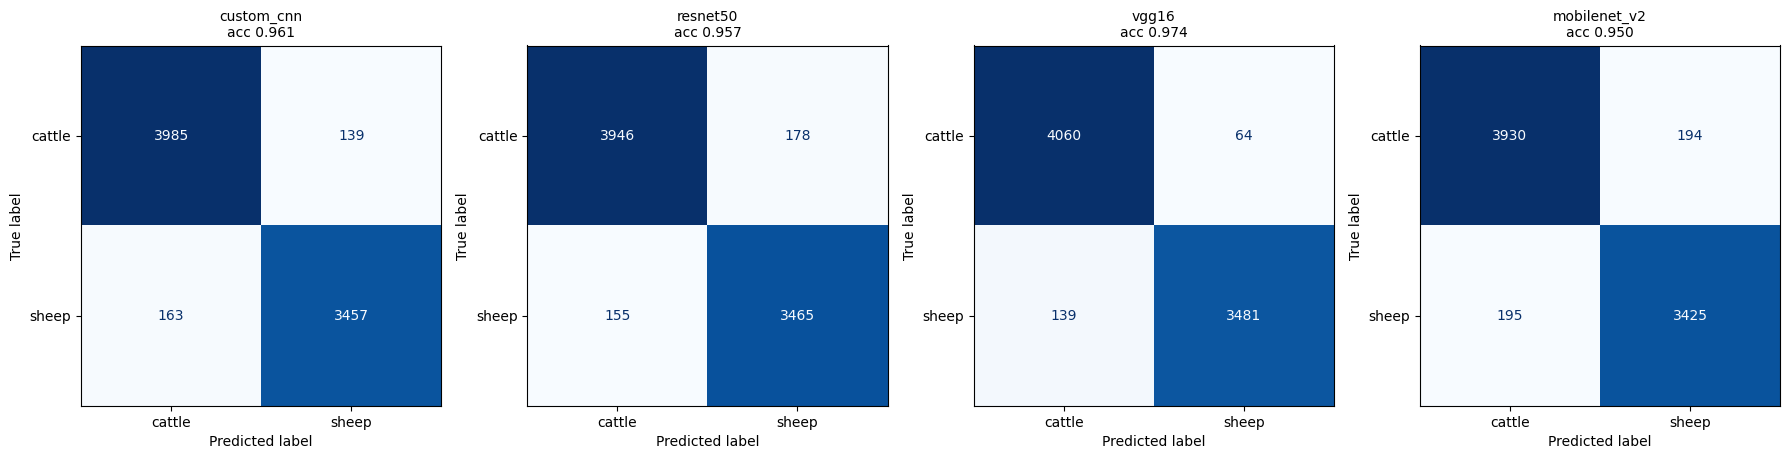

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
for ax, name in zip(axes, CLASSIFIERS):
    cm = np.array(results[name]["confusion_matrix"])
    ConfusionMatrixDisplay(cm, display_labels=classes).plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(f"{name}\nacc {results[name]['test_acc']:.3f}", fontsize=10)
plt.tight_layout()
plt.savefig(RUNS_BASE / "all_confusion_matrices.png", dpi=100, bbox_inches="tight")
plt.show()


In [5]:
def mcnemar_pvalue(y_true_arr, y_a, y_b):
    a_correct = y_a == y_true_arr
    b_correct = y_b == y_true_arr
    table = [
        [int((a_correct & b_correct).sum()),  int((a_correct & ~b_correct).sum())],
        [int((~a_correct & b_correct).sum()), int((~a_correct & ~b_correct).sum())],
    ]
    return mcnemar(table, exact=False, correction=True).pvalue, table


print("McNemar test pairwise (H0: same error rate; p < 0.05 = significant difference)")
print()
n = len(CLASSIFIERS)
p_matrix = pd.DataFrame(np.full((n, n), np.nan), index=CLASSIFIERS, columns=CLASSIFIERS)
for i, a in enumerate(CLASSIFIERS):
    for j, b in enumerate(CLASSIFIERS):
        if i < j:
            p_val, _ = mcnemar_pvalue(y_true, ps_dict[a], ps_dict[b])
            p_matrix.iloc[i, j] = p_val

print("p-values (upper triangle):")
print(p_matrix.round(6).to_string())

print()
print("interpretation:")
for i, a in enumerate(CLASSIFIERS):
    for j, b in enumerate(CLASSIFIERS):
        if i < j:
            p_val = p_matrix.iloc[i, j]
            verdict = "DIFFERENT" if p_val < 0.05 else "no significant diff"
            acc_a = results[a]["test_acc"]
            acc_b = results[b]["test_acc"]
            winner = a if acc_a > acc_b else b
            print(f"  {a} vs {b}: p={p_val:.4e} -> {verdict}  (better: {winner})")


McNemar test pairwise (H0: same error rate; p < 0.05 = significant difference)

p-values (upper triangle):
              custom_cnn  resnet50  vgg16  mobilenet_v2
custom_cnn           NaN  0.147501    0.0      0.000047
resnet50             NaN       NaN    0.0      0.009049
vgg16                NaN       NaN    NaN      0.000000
mobilenet_v2         NaN       NaN    NaN           NaN

interpretation:
  custom_cnn vs resnet50: p=1.4750e-01 -> no significant diff  (better: custom_cnn)
  custom_cnn vs vgg16: p=2.7434e-08 -> DIFFERENT  (better: vgg16)
  custom_cnn vs mobilenet_v2: p=4.7488e-05 -> DIFFERENT  (better: custom_cnn)
  resnet50 vs vgg16: p=1.2010e-11 -> DIFFERENT  (better: vgg16)
  resnet50 vs mobilenet_v2: p=9.0493e-03 -> DIFFERENT  (better: resnet50)
  vgg16 vs mobilenet_v2: p=1.4194e-21 -> DIFFERENT  (better: vgg16)


In [6]:
test_ds_meta = ImageFolder(DATA_CROPS / "test")
test_filenames = [Path(p).name for p, _ in test_ds_meta.samples]
print("test crops in alphabetic order:", len(test_filenames))


def crop_to_image(crop_name):
    stem = Path(crop_name).stem
    parts = stem.rsplit("_", 1)
    return parts[0] + ".jpg"


subgroup_df = pd.read_csv(DATA_PROCESSED / "subgroup_labels.csv")
img_to_lighting = dict(zip(subgroup_df["image_id"], subgroup_df["lighting"]))
img_to_occlusion = dict(zip(subgroup_df["image_id"], subgroup_df["occlusion"]))

result_df = pd.DataFrame({
    "filename": test_filenames,
    "y_true": y_true,
    "lighting": [img_to_lighting.get(crop_to_image(f), "unknown") for f in test_filenames],
    "occlusion": [img_to_occlusion.get(crop_to_image(f), "unknown") for f in test_filenames],
})
for name in CLASSIFIERS:
    result_df[f"y_{name}"] = ps_dict[name]
    result_df[f"correct_{name}"] = (ps_dict[name] == y_true).astype(int)

print()
print("subgroup distribution in test crops:")
print(f"  lighting:  {result_df['lighting'].value_counts().to_dict()}")
print(f"  occlusion: {result_df['occlusion'].value_counts().to_dict()}")
unknown_n = (result_df["lighting"] == "unknown").sum()
if unknown_n > 0:
    print(f"  WARNING: {unknown_n} crops with unknown subgroup (image not found in subgroup_labels)")


test crops in alphabetic order: 7744

subgroup distribution in test crops:
  lighting:  {'overcast': 6036, 'dim': 879, 'bright': 829}
  occlusion: {'low': 3663, 'high': 2066, 'medium': 2015}


per-subgroup classification accuracy

=== lighting ===
          custom_cnn  resnet50   vgg16  mobilenet_v2
lighting                                            
bright        0.9602    0.9517  0.9723        0.9180
dim           0.9693    0.9750  0.9784        0.9579
overcast      0.9599    0.9551  0.9733        0.9529

=== occlusion ===
           custom_cnn  resnet50   vgg16  mobilenet_v2
occlusion                                            
high           0.9603    0.9705  0.9724        0.9584
low            0.9689    0.9544  0.9776        0.9552
medium         0.9474    0.9479  0.9682        0.9310


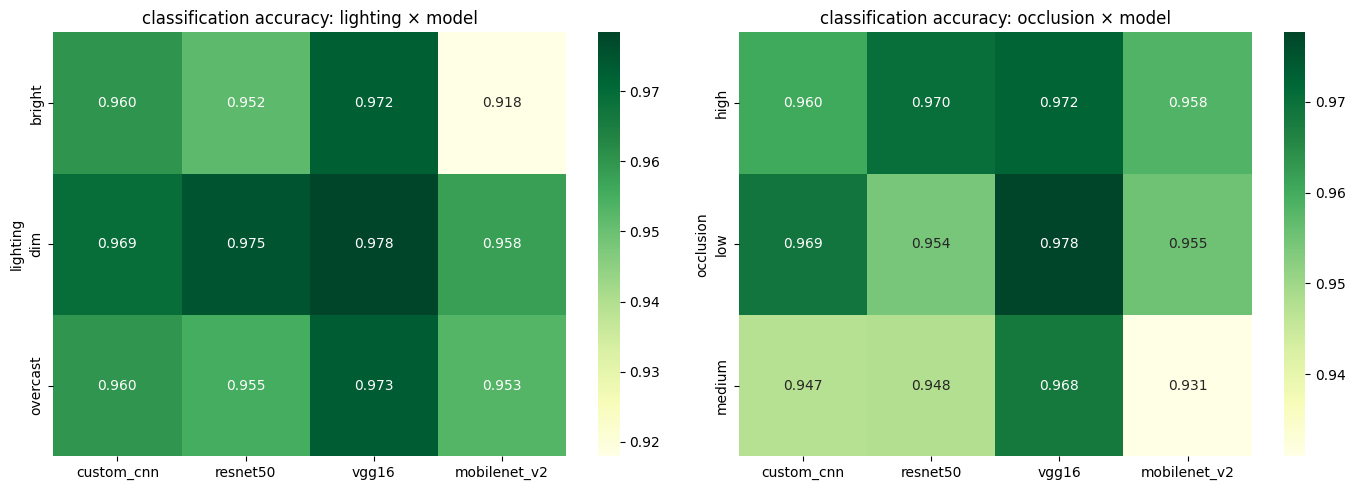

In [7]:
ltable = pd.DataFrame({
    name: result_df.groupby("lighting")[f"correct_{name}"].mean()
    for name in CLASSIFIERS
})
otable = pd.DataFrame({
    name: result_df.groupby("occlusion")[f"correct_{name}"].mean()
    for name in CLASSIFIERS
})

print("per-subgroup classification accuracy")
print()
print("=== lighting ===")
print(ltable.round(4).to_string())
print()
print("=== occlusion ===")
print(otable.round(4).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(ltable, annot=True, fmt=".3f", cmap="YlGn", ax=axes[0])
axes[0].set_title("classification accuracy: lighting × model")
sns.heatmap(otable, annot=True, fmt=".3f", cmap="YlGn", ax=axes[1])
axes[1].set_title("classification accuracy: occlusion × model")
plt.tight_layout()
plt.savefig(RUNS_BASE / "subgroup_heatmaps.png", dpi=100, bbox_inches="tight")
plt.show()


yolov8 counting MAE by subgroup

=== lighting ===
           mean  median  count
lighting                      
bright    2.107     1.0    196
dim       0.932     0.0    206
overcast  1.596     1.0   1433

=== occlusion ===
            mean  median  count
occlusion                      
high       3.559     2.0    433
low        0.650     0.0    960
medium     1.645     1.0    442


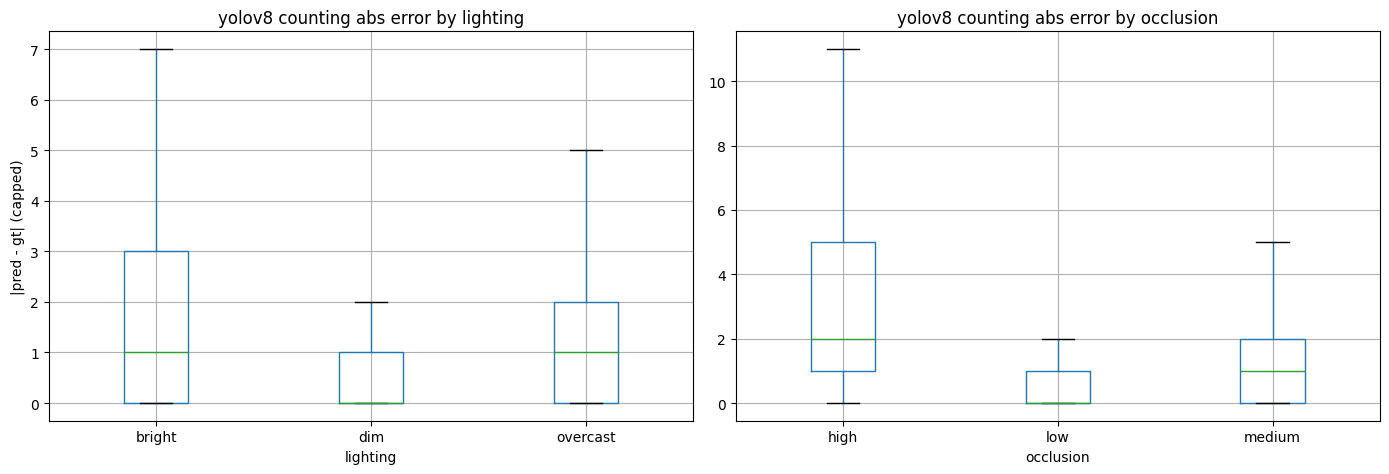

In [8]:
import cv2

YOLO_TEST_IMG_DIR = DATA_PROCESSED / "images" / "test"
YOLO_TEST_LBL_DIR = DATA_PROCESSED / "labels" / "test"


def lighting_for(img_path):
    bgr = cv2.imread(str(img_path))
    if bgr is None:
        return "unknown"
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    hsv = cv2.cvtColor(rgb, cv2.COLOR_RGB2HSV)
    v = hsv[..., 2].mean() / 255.0
    if v < 0.35:
        return "dim"
    if v < 0.65:
        return "overcast"
    return "bright"


def box_iou_yolo(a, b):
    ax1, ay1, ax2, ay2 = a
    bx1, by1, bx2, by2 = b
    ix1, iy1 = max(ax1, bx1), max(ay1, by1)
    ix2, iy2 = min(ax2, bx2), min(ay2, by2)
    iw, ih = max(0.0, ix2 - ix1), max(0.0, iy2 - iy1)
    inter = iw * ih
    area_a = max(0.0, ax2 - ax1) * max(0.0, ay2 - ay1)
    area_b = max(0.0, bx2 - bx1) * max(0.0, by2 - by1)
    union = area_a + area_b - inter
    return inter / union if union > 0 else 0.0


def occlusion_for(image_name):
    lbl = YOLO_TEST_LBL_DIR / (Path(image_name).stem + ".txt")
    if not lbl.exists():
        return "low"
    boxes = []
    for line in lbl.read_text().strip().splitlines():
        parts = line.split()
        if len(parts) >= 5:
            cx, cy, w, h = map(float, parts[1:5])
            boxes.append((cx - w/2, cy - h/2, cx + w/2, cy + h/2))
    if len(boxes) < 2:
        return "low"
    max_iou = 0.0
    for i in range(len(boxes)):
        for j in range(i + 1, len(boxes)):
            max_iou = max(max_iou, box_iou_yolo(boxes[i], boxes[j]))
    if max_iou < 0.1:
        return "low"
    if max_iou < 0.3:
        return "medium"
    return "high"


yolo_counts = pd.read_csv(RUNS_BASE / "yolov8" / "test_counts.csv")
yolo_counts["lighting"]  = [lighting_for(YOLO_TEST_IMG_DIR / name) for name in yolo_counts["image_id"]]
yolo_counts["occlusion"] = [occlusion_for(name) for name in yolo_counts["image_id"]]
yolo_counts["abs_err"]   = (yolo_counts["pred_count"] - yolo_counts["gt_count"]).abs()

print("yolov8 counting MAE by subgroup")
print()
print("=== lighting ===")
print(yolo_counts.groupby("lighting")["abs_err"].agg(["mean", "median", "count"]).round(3).to_string())
print()
print("=== occlusion ===")
print(yolo_counts.groupby("occlusion")["abs_err"].agg(["mean", "median", "count"]).round(3).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
yolo_counts.boxplot(column="abs_err", by="lighting", ax=axes[0], showfliers=False)
axes[0].set_title("yolov8 counting abs error by lighting")
axes[0].set_xlabel("lighting")
axes[0].set_ylabel("|pred - gt| (capped)")
yolo_counts.boxplot(column="abs_err", by="occlusion", ax=axes[1], showfliers=False)
axes[1].set_title("yolov8 counting abs error by occlusion")
axes[1].set_xlabel("occlusion")
plt.suptitle("")
plt.tight_layout()
plt.savefig(RUNS_BASE / "yolo_subgroup_counting.png", dpi=100, bbox_inches="tight")
plt.show()


In [9]:
print("=" * 60)
print("HYPOTHESIS TESTS")
print("=" * 60)

custom_acc = results["custom_cnn"]["test_acc"]

print()
print("H1: ImageNet-pretrained models outperform custom CNN baseline")
print(f"  custom CNN test acc: {custom_acc:.4f}")
better_count = 0
for pret in ("resnet50", "vgg16", "mobilenet_v2"):
    pret_acc = results[pret]["test_acc"]
    delta = pret_acc - custom_acc
    p_val, _ = mcnemar_pvalue(y_true, ps_dict["custom_cnn"], ps_dict[pret])
    sig = "* significant" if p_val < 0.05 else "  not significant"
    print(f"  {pret}: acc={pret_acc:.4f}, delta={delta:+.4f}, McNemar p={p_val:.4e} {sig}")
    if pret_acc > custom_acc and p_val < 0.05:
        better_count += 1

if better_count == 3:
    h1 = "SUPPORTED (all 3 pretrained beat custom CNN significantly)"
elif better_count == 0:
    h1 = "REJECTED (no pretrained model significantly outperforms custom CNN)"
else:
    h1 = f"PARTIALLY SUPPORTED ({better_count}/3 pretrained beat custom CNN significantly)"
print(f"  H1 conclusion: {h1}")

print()
print("H2: data augmentation improves generalization (custom CNN ablation)")
with open(RUNS_BASE / "baseline_cnn" / "ablation_results.json") as f:
    ablation = json.load(f)
print(f"  with augmentation:    test acc = {custom_acc:.4f}")
print(f"  without augmentation: test acc = {ablation['test_acc']:.4f}")
delta_aug = custom_acc - ablation["test_acc"]
print(f"  delta (with - without): {delta_aug:+.4f}")
if delta_aug > 0:
    h2 = f"SUPPORTED (augmentation gives +{delta_aug*100:.2f}pp accuracy)"
else:
    h2 = "REJECTED (augmentation does not help on test set)"
print(f"  H2 conclusion: {h2}")

print()
print("H3: YOLOv8 counting outperforms naive baselines")
yolo_mae = yolo["counting"]["mae"]
yolo_r2 = yolo["counting"]["r2"]
median_count = yolo_counts["gt_count"].median()
mean_count = yolo_counts["gt_count"].mean()
naive_median_mae = mean_absolute_error(
    yolo_counts["gt_count"], np.full(len(yolo_counts), median_count)
)
naive_mean_mae = mean_absolute_error(
    yolo_counts["gt_count"], np.full(len(yolo_counts), mean_count)
)
print(f"  YOLOv8 counting MAE: {yolo_mae:.3f}  (R^2 = {yolo_r2:.3f})")
print(f"  naive (always median = {median_count:.0f}): MAE = {naive_median_mae:.3f}")
print(f"  naive (always mean   = {mean_count:.2f}): MAE = {naive_mean_mae:.3f}")
if yolo_mae < naive_median_mae and yolo_mae < naive_mean_mae:
    h3 = f"SUPPORTED (YOLO MAE {yolo_mae:.2f} << naive baselines)"
else:
    h3 = "REJECTED (YOLO not better than naive)"
print(f"  H3 conclusion: {h3}")


HYPOTHESIS TESTS

H1: ImageNet-pretrained models outperform custom CNN baseline
  custom CNN test acc: 0.9610
  resnet50: acc=0.9570, delta=-0.0040, McNemar p=1.4750e-01   not significant
  vgg16: acc=0.9738, delta=+0.0128, McNemar p=2.7434e-08 * significant
  mobilenet_v2: acc=0.9498, delta=-0.0112, McNemar p=4.7488e-05 * significant
  H1 conclusion: PARTIALLY SUPPORTED (1/3 pretrained beat custom CNN significantly)

H2: data augmentation improves generalization (custom CNN ablation)
  with augmentation:    test acc = 0.9610
  without augmentation: test acc = 0.9548
  delta (with - without): +0.0062
  H2 conclusion: SUPPORTED (augmentation gives +0.62pp accuracy)

H3: YOLOv8 counting outperforms naive baselines
  YOLOv8 counting MAE: 1.576  (R^2 = 0.975)
  naive (always median = 11): MAE = 11.962
  naive (always mean   = 17.07): MAE = 13.529
  H3 conclusion: SUPPORTED (YOLO MAE 1.58 << naive baselines)


In [10]:
print("=" * 70)
print("FINAL COMPARATIVE SUMMARY")
print("=" * 70)
print()

print("CLASSIFICATION (test set: 7744 single-animal crops)")
print("-" * 70)
header = f"{'model':14s} {'acc':>8s} {'P':>7s} {'R':>7s} {'F1':>7s} {'params':>15s}"
print(header)
for name in CLASSIFIERS:
    r = results[name]
    p_count = r.get("n_params_total", 8760706)
    print(f"{name:14s} {r['test_acc']:>8.4f} {r['precision']:>7.4f} {r['recall']:>7.4f} {r['f1']:>7.4f} {p_count:>15,}")

best_clf = max(CLASSIFIERS, key=lambda n: results[n]["test_acc"])
print()
print(f"best classifier: {best_clf} (test acc {results[best_clf]['test_acc']:.4f})")

print()
print("DETECTION + COUNTING (yolov8n, 1835 full test images)")
print("-" * 70)
print(f"  detection mAP@50:     {yolo['detection']['map50']:.4f}")
print(f"  detection mAP@50-95:  {yolo['detection']['map']:.4f}")
print(f"  counting MAE:         {yolo['counting']['mae']:.3f} animals/image")
print(f"  counting R^2:         {yolo['counting']['r2']:.4f}")
print(f"  exact count match:    {yolo['counting']['exact_match_pct']:.1f}% of images")

print()
print("RESEARCH QUESTIONS")
print("-" * 70)
print()
print("RQ1: can a custom CNN baseline match ImageNet-pretrained models?")
better_models = [p for p in ("resnet50", "vgg16", "mobilenet_v2") if results[p]["test_acc"] > custom_acc]
print(f"  custom CNN beat by {len(better_models)}/3 pretrained: {better_models or 'none'}")
print(f"  custom CNN ranks {sorted(CLASSIFIERS, key=lambda n: -results[n]['test_acc']).index('custom_cnn')+1}/4 by test accuracy")

print()
print("RQ2: how robust are models to varied lighting and occlusion?")
worst_l = ltable.min().min()
worst_o = otable.min().min()
print(f"  worst classification accuracy by lighting:  {worst_l:.3f}")
print(f"  worst classification accuracy by occlusion: {worst_o:.3f}")
print(f"  see subgroup_heatmaps.png for full breakdown")

print()
print("RQ3: can a single-stage detector provide accurate counting?")
print(f"  YOLOv8 counting R^2 = {yolo['counting']['r2']:.4f}")
print(f"  exact match rate = {yolo['counting']['exact_match_pct']:.1f}%")
print(f"  yes, significantly better than naive predictors (see H3)")

final_clf_table = pd.DataFrame([
    {"model": n, "test_acc": results[n]["test_acc"], "precision": results[n]["precision"],
     "recall": results[n]["recall"], "f1": results[n]["f1"]}
    for n in CLASSIFIERS
])
final_clf_table.to_csv(RUNS_BASE / "final_classification_summary.csv", index=False)

final_yolo_summary = {
    "model": "yolov8n",
    "detection_map50": yolo["detection"]["map50"],
    "detection_map": yolo["detection"]["map"],
    "counting_mae": yolo["counting"]["mae"],
    "counting_r2": yolo["counting"]["r2"],
    "counting_exact_match_pct": yolo["counting"]["exact_match_pct"],
}
with open(RUNS_BASE / "final_yolo_summary.json", "w") as f:
    json.dump(final_yolo_summary, f, indent=2)

print()
print("saved:")
print(f"  {RUNS_BASE / 'final_classification_summary.csv'}")
print(f"  {RUNS_BASE / 'final_yolo_summary.json'}")
print(f"  {RUNS_BASE / 'all_confusion_matrices.png'}")
print(f"  {RUNS_BASE / 'subgroup_heatmaps.png'}")
print(f"  {RUNS_BASE / 'yolo_subgroup_counting.png'}")


FINAL COMPARATIVE SUMMARY

CLASSIFICATION (test set: 7744 single-animal crops)
----------------------------------------------------------------------
model               acc       P       R      F1          params
custom_cnn       0.9610  0.9610  0.9606  0.9608       8,760,706
resnet50         0.9570  0.9567  0.9570  0.9568      23,770,562
vgg16            0.9738  0.9744  0.9730  0.9736      17,926,338
mobilenet_v2     0.9498  0.9496  0.9495  0.9496       2,388,098

best classifier: vgg16 (test acc 0.9738)

DETECTION + COUNTING (yolov8n, 1835 full test images)
----------------------------------------------------------------------
  detection mAP@50:     0.9478
  detection mAP@50-95:  0.6007
  counting MAE:         1.576 animals/image
  counting R^2:         0.9749
  exact count match:    46.7% of images

RESEARCH QUESTIONS
----------------------------------------------------------------------

RQ1: can a custom CNN baseline match ImageNet-pretrained models?
  custom CNN beat by 1/3 pre